# Task 4: Predicting Insurance Claim Amounts
## DevelopersHub Corporation – Data Science & Analytics Internship

### Problem Statement
Medical insurance companies need to estimate the claim amount for policyholders in order to set premiums appropriately. This task builds a **regression model to predict medical insurance charges** based on personal attributes such as age, BMI, smoking status, and number of dependents.

### Dataset Description
- **Dataset**: Medical Cost Personal Dataset
- **Rows**: 1,338 | **Columns**: 7
- **Target Variable**: `charges` (medical insurance claim amount in USD)
- **Features**: age, sex, bmi, children, smoker, region


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('medical_insurance.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded: 1338 rows × 7 columns


,age,sex,bmi,children,smoker,region,charges
0,56,male,28.48,0,yes,southeast,48678.26
1,46,female,31.81,2,no,northeast,16828.87
2,32,male,21.85,0,no,southwest,10023.46
3,60,male,34.14,1,no,northwest,19397.84
4,25,male,21.30,1,no,northwest,9560.63
5,38,male,25.73,0,no,northwest,13933.13
6,56,female,38.78,0,no,northeast,20571.89
7,36,male,25.21,1,no,northwest,13314.02
8,40,male,34.10,0,no,northwest,13769.07
9,28,male,19.90,1,no,southwest,10539.53


## 3. Dataset Understanding

In [3]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [4]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,40.48,30.54,1.05,21587.84
std,13.12,5.97,1.18,14717.82
min,18.00,10.00,0.00,4635.52
25%,29.00,26.40,0.00,12289.86
50%,41.00,30.66,1.00,16267.10
75%,52.00,34.52,2.00,20225.56
max,63.00,48.69,5.00,64894.15


In [5]:
print(f"Missing Values: {df.isnull().sum().sum()}")
print("\nSmoker distribution:")
print(df['smoker'].value_counts())
print("\nRegion distribution:")
print(df['region'].value_counts())

Missing Values: 0

Smoker distribution:
smoker
no     1073
yes     265
Name: count, dtype: int64

Region distribution:
region
northwest    351
southwest    336
southeast    327
northeast    324
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

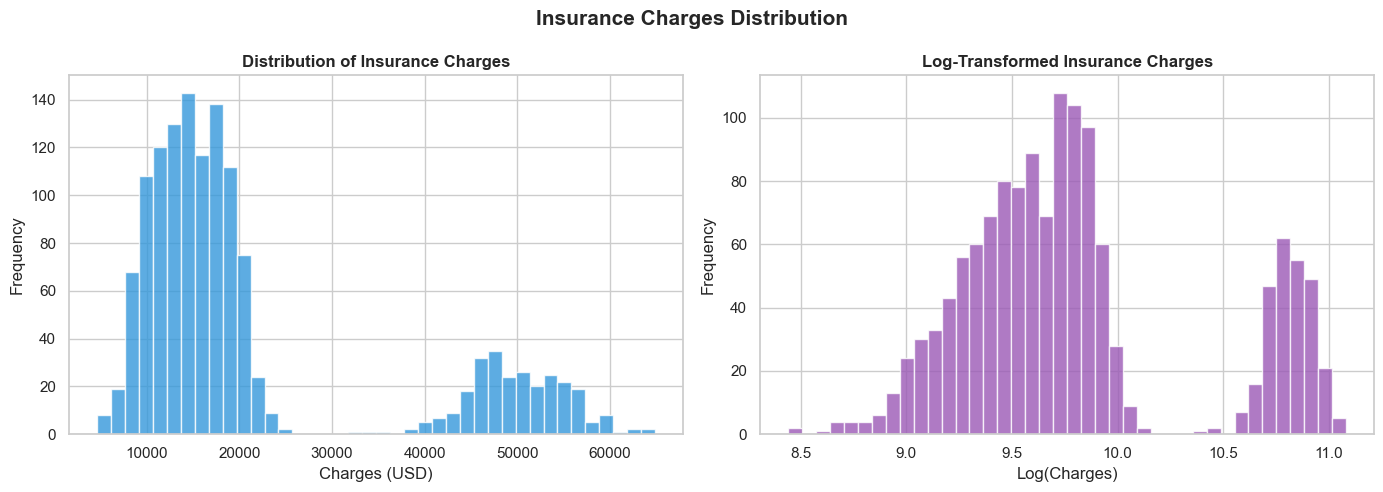

Observation: Charges are right-skewed; log transformation makes it more normal.


In [6]:
# Charges distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['charges'], bins=40, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Insurance Charges', fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')

# Log-transformed charges
axes[1].hist(np.log(df['charges']), bins=40, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Insurance Charges', fontweight='bold')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Insurance Charges Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Charges are right-skewed; log transformation makes it more normal.")

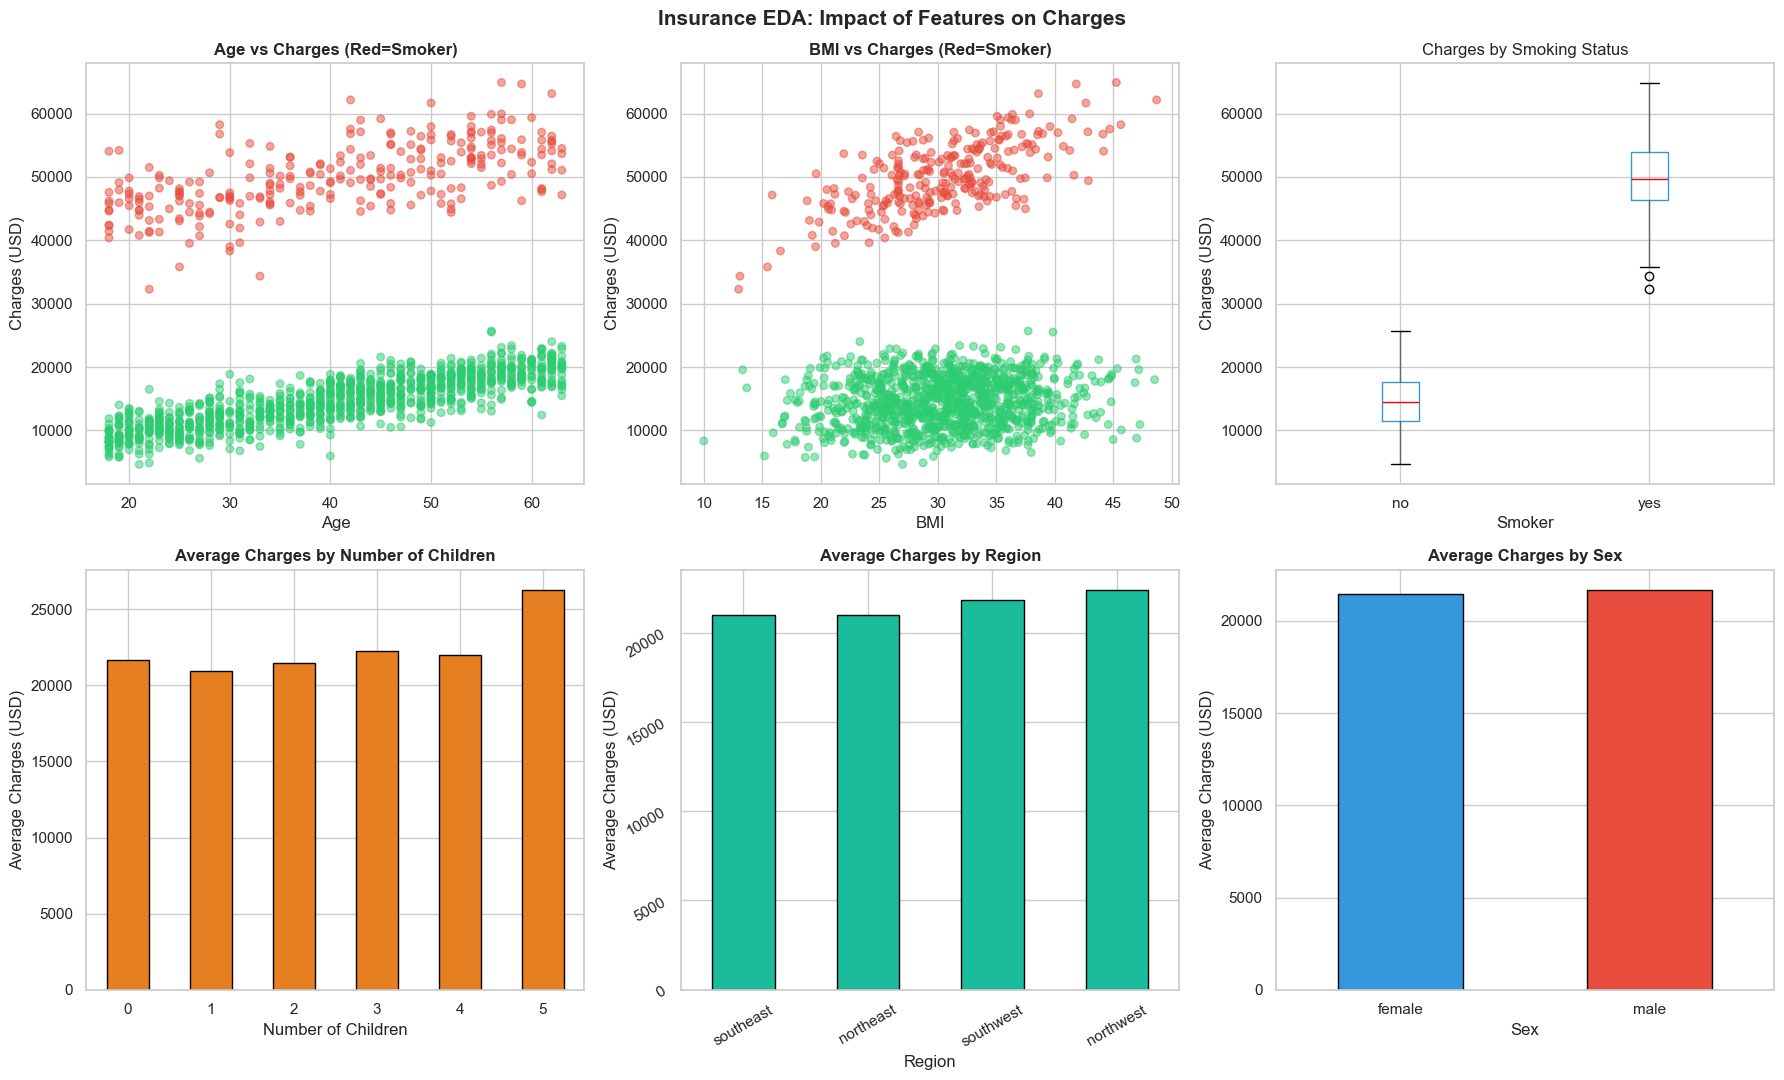

Key Observation: Smoking status has the single largest impact on insurance charges!


In [7]:
# Impact of key features on charges
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Age vs Charges
axes[0,0].scatter(df['age'], df['charges'], 
                  c=df['smoker'].map({'yes':'#E74C3C','no':'#2ECC71'}), alpha=0.5, s=30)
axes[0,0].set_title('Age vs Charges (Red=Smoker)', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Charges (USD)')

# BMI vs Charges
axes[0,1].scatter(df['bmi'], df['charges'],
                  c=df['smoker'].map({'yes':'#E74C3C','no':'#2ECC71'}), alpha=0.5, s=30)
axes[0,1].set_title('BMI vs Charges (Red=Smoker)', fontweight='bold')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Charges (USD)')

# Smoker vs Charges box plot
df.boxplot(column='charges', by='smoker', ax=axes[0,2],
           boxprops=dict(color='#3498DB'), medianprops=dict(color='red'))
axes[0,2].set_title('Charges by Smoking Status', fontweight='bold')
axes[0,2].set_xlabel('Smoker')
axes[0,2].set_ylabel('Charges (USD)')
plt.sca(axes[0,2])
plt.title('Charges by Smoking Status')

# Children vs Charges
churn_ch = df.groupby('children')['charges'].mean()
churn_ch.plot(kind='bar', ax=axes[1,0], color='#E67E22', edgecolor='black')
axes[1,0].set_title('Average Charges by Number of Children', fontweight='bold')
axes[1,0].set_xlabel('Number of Children')
axes[1,0].set_ylabel('Average Charges (USD)')
axes[1,0].tick_params(rotation=0)

# Region vs Charges
df.groupby('region')['charges'].mean().sort_values().plot(
    kind='bar', ax=axes[1,1], color='#1ABC9C', edgecolor='black')
axes[1,1].set_title('Average Charges by Region', fontweight='bold')
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Average Charges (USD)')
axes[1,1].tick_params(rotation=30)

# Sex vs Charges
df.groupby('sex')['charges'].mean().plot(
    kind='bar', ax=axes[1,2], color=['#3498DB','#E74C3C'], edgecolor='black')
axes[1,2].set_title('Average Charges by Sex', fontweight='bold')
axes[1,2].set_xlabel('Sex')
axes[1,2].set_ylabel('Average Charges (USD)')
axes[1,2].tick_params(rotation=0)

plt.suptitle('Insurance EDA: Impact of Features on Charges', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('insurance_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key Observation: Smoking status has the single largest impact on insurance charges!")

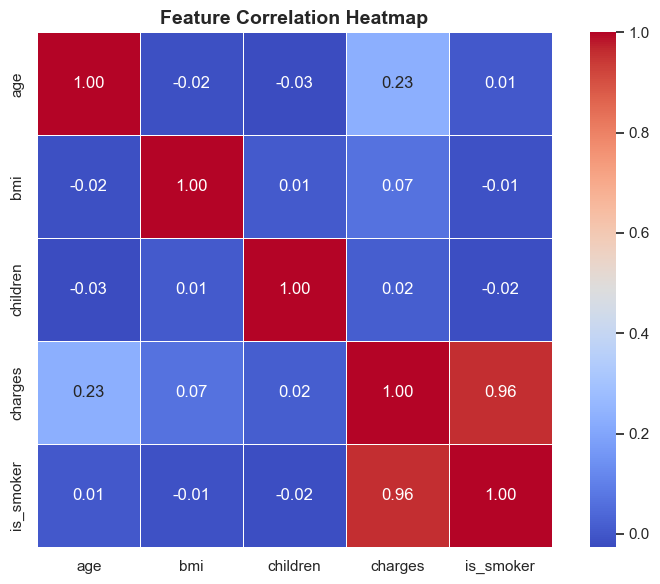

In [8]:
# Correlation heatmap (numerical features)
plt.figure(figsize=(8, 6))
num_df = df[['age','bmi','children','charges']].copy()
num_df['is_smoker'] = (df['smoker'] == 'yes').astype(int)
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insurance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Encoding

In [9]:
df_model = df.copy()

# Encode categorical features
le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex'])
df_model['smoker'] = le.fit_transform(df_model['smoker'])
df_model['region'] = le.fit_transform(df_model['region'])

print("Encoded: sex, smoker, region")
print("\nEncoded dataset:")
df_model.head()

Encoded: sex, smoker, region

Encoded dataset:


,age,sex,bmi,children,smoker,region,charges
0,56,1,28.48,0,1,2,48678.26
1,46,0,31.81,2,0,0,16828.87
2,32,1,21.85,0,0,3,10023.46
3,60,1,34.14,1,0,1,19397.84
4,25,1,21.30,1,0,1,9560.63


## 6. Model Training

In [10]:
X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features: {list(X.columns)}")

Training samples: 1070
Testing samples:  268
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [11]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"  MAE  : ${lr_mae:,.2f}")
print(f"  RMSE : ${lr_rmse:,.2f}")
print(f"  R²   : {lr_r2:.4f}")

Linear Regression Results:
  MAE  : $1,811.28
  RMSE : $2,288.99
  R²   : 0.9722


In [12]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Regressor Results:")
print(f"  MAE  : ${rf_mae:,.2f}")
print(f"  RMSE : ${rf_rmse:,.2f}")
print(f"  R²   : {rf_r2:.4f}")

Random Forest Regressor Results:
  MAE  : $1,742.77
  RMSE : $2,275.76
  R²   : 0.9725


## 7. Model Evaluation

In [13]:
# Model comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)': [f"{lr_mae:,.0f}", f"{rf_mae:,.0f}"],
    'RMSE ($)': [f"{lr_rmse:,.0f}", f"{rf_rmse:,.0f}"],
    'R² Score': [f"{lr_r2:.4f}", f"{rf_r2:.4f}"]
})
print("Model Performance Comparison:")
print(comparison.to_string(index=False))

Model Performance Comparison:
            Model MAE ($) RMSE ($) R² Score
Linear Regression   1,811    2,289   0.9722
    Random Forest   1,743    2,276   0.9725


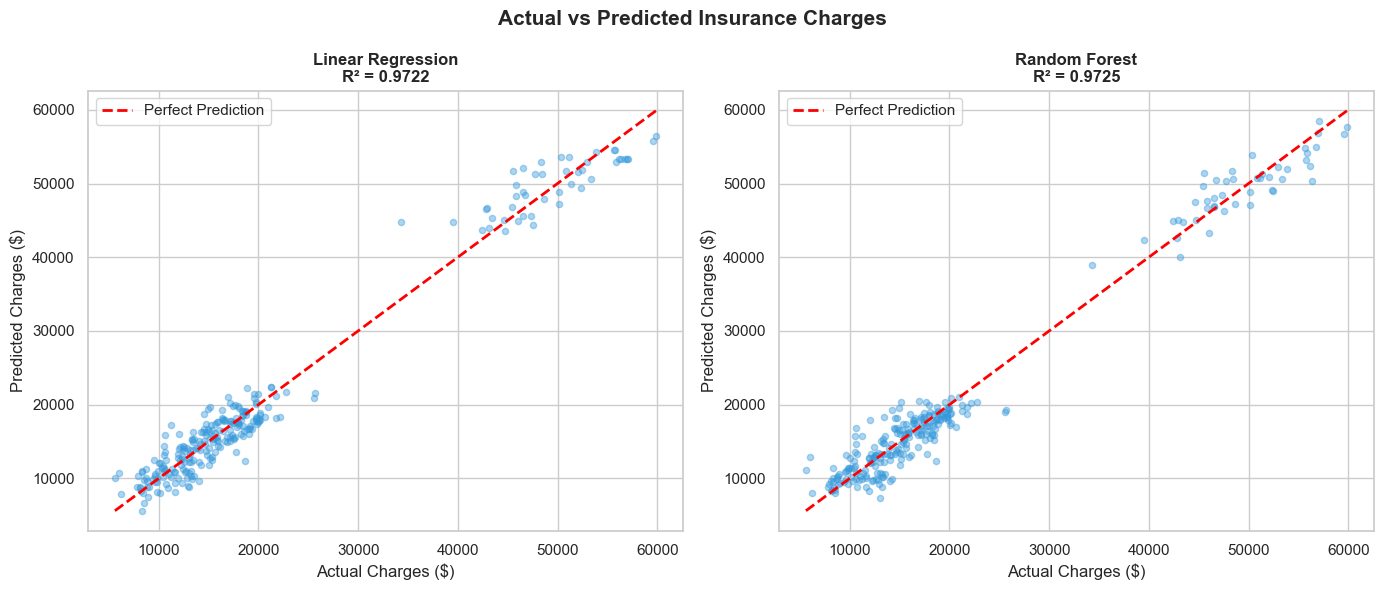

In [14]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models_info = [('Linear Regression', lr_pred, lr_r2), ('Random Forest', rf_pred, rf_r2)]

for ax, (name, pred, r2) in zip(axes, models_info):
    ax.scatter(y_test, pred, alpha=0.4, color='#3498DB', s=20)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect Prediction')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.legend()

plt.suptitle('Actual vs Predicted Insurance Charges', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

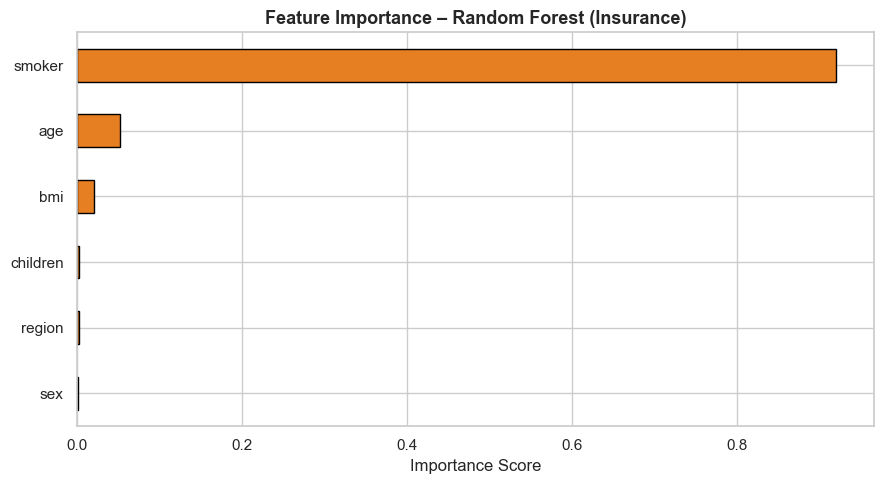


Top Features:
smoker      0.920096
age         0.052786
bmi         0.021013
children    0.002924
region      0.002150
dtype: float64


In [15]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='#E67E22', edgecolor='black')
plt.title('Feature Importance – Random Forest (Insurance)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('insurance_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop Features:")
print(importances.sort_values(ascending=False).head(5))

## 8. Conclusion

### Key Insights:

1. **Smoking is the #1 Factor**: Smokers pay dramatically more in insurance charges — often 3-4x more than non-smokers. This is the strongest predictor.

2. **BMI × Smoking Interaction**: High BMI combined with smoking creates extreme charges. The scatter plot shows a distinct upper cluster of smokers with high BMI.

3. **Age Increases Charges**: There's a clear positive relationship between age and charges, even after accounting for smoking.

4. **Region Has Minimal Impact**: Geographic region has a relatively minor effect on charges compared to health-related factors.

5. **Random Forest > Linear Regression**: The non-linear relationships (especially for smokers) make Random Forest a significantly better predictor.

### Evaluation Metrics:
| Metric | Formula | Meaning |
|--------|---------|---------|
| **MAE** | Mean of |actual - predicted| | Average dollar error |
| **RMSE** | √(Mean of (actual - predicted)²) | Penalizes large errors more |
| **R²** | 1 - SS_res/SS_tot | % variance explained (1.0 = perfect) |

### Skills Applied:
- Regression modeling (Linear Regression & Random Forest Regressor)
- Feature correlation and visualization (scatter, box, heatmap)
- Error evaluation using MAE and RMSE
- Feature importance interpretation
